<h1 style="font-size:40px;">Exploratory Data Analysis (EDA)</h1>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("customer_churn.csv")

In [3]:
df.head(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 7.1 MB


In [5]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
df['Gender'].unique()

<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

In [7]:
df['Gender'] = df['Gender'].map({"Female": 0, "Male": 1})

In [8]:
df['Gender'].astype(int)

0        0
1        0
2        1
3        1
4        0
        ..
64369    0
64370    1
64371    1
64372    0
64373    0
Name: Gender, Length: 64374, dtype: int64

In [9]:
df.head(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,0,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,0,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,1,27,10,2,29,Premium,Annual,757,21,0
3,4,35,1,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,0,58,24,9,2,Standard,Annual,533,18,0


In [10]:
df.drop('CustomerID', axis=1, inplace=True)

In [11]:
df.isnull().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

Age                  int64
Gender               int64
Tenure               int64
Usage Frequency      int64
Support Calls        int64
Payment Delay        int64
Subscription Type      str
Contract Length        str
Total Spend          int64
Last Interaction     int64
Churn                int64
dtype: object

In [14]:
df['Churn'].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

Text(0.5, 1.0, 'Churn Distribution')

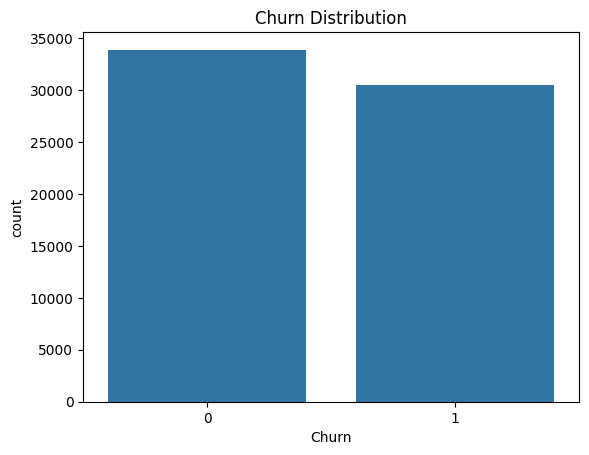

In [15]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")

In [16]:
df['Subscription Type'].value_counts()

Subscription Type
Standard    21502
Basic       21451
Premium     21421
Name: count, dtype: int64

In [17]:
df['Subscription Type'] = df['Subscription Type'].str.strip().map({"Premium":2, "Standard":1, "Basic":0})

In [18]:
df['Subscription Type'].astype(int)

0        0
1        1
2        2
3        2
4        1
        ..
64369    0
64370    1
64371    2
64372    1
64373    1
Name: Subscription Type, Length: 64374, dtype: int64

In [19]:
df['Contract Length'].unique()

<ArrowStringArray>
['Monthly', 'Annual', 'Quarterly']
Length: 3, dtype: str

<Axes: xlabel='Contract Length', ylabel='count'>

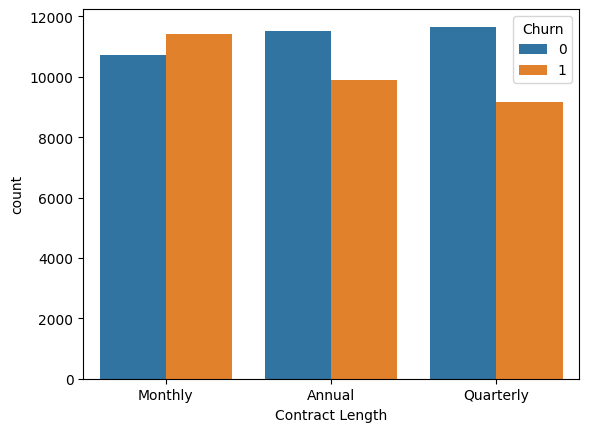

In [20]:
sns.countplot(x= 'Contract Length', hue='Churn', data= df)